# **Building the best stacked model - without tuning**

**Import packages and data**

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
from sklearn.isotonic import IsotonicRegression
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    precision_score,
    recall_score,
    brier_score_loss, f1_score)
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import shap

In [2]:
df=pd.read_csv("final_merged_cleaned_preprocessed.csv")
df.head()

,patientunitstayid,age,admissionheight,admissionweight,bmi,dialysis,wbc,respiratoryrate,sodium,heartrate,...,unittype_Cardiac ICU,unittype_MICU,unittype_Med-Surg ICU,unittype_Neuro ICU,unittype_SICU,region_Northeast,region_South,region_Unknown,region_West,bad_outcome
0,141764,87.0,157.5,79.3,27.298480,0.0,9.9,27.0,138.0,104.0,...,0,0,1,0,0,0,0,0,0,1
1,141765,87.0,157.5,46.5,18.745276,0.0,10.2,39.0,139.0,88.0,...,0,0,1,0,0,0,0,0,0,0
2,143870,76.0,167.0,77.5,27.788734,0.0,11.7,60.0,133.0,40.0,...,0,0,0,0,1,0,0,0,0,0
3,144815,34.0,172.7,60.3,20.217741,0.0,7.9,6.0,141.0,131.0,...,0,0,1,0,0,0,0,0,0,0
4,145427,61.0,177.8,91.7,29.007201,0.0,21.1,41.0,141.0,49.0,...,0,0,0,0,1,0,0,0,0,0


In [3]:
df.columns

Index(['patientunitstayid', 'age', 'admissionheight', 'admissionweight', 'bmi',
       'dialysis', 'wbc', 'respiratoryrate', 'sodium', 'heartrate', 'meanbp',
       'ph', 'hematocrit', 'creatinine', 'albumin', 'pao2', 'pco2', 'bun',
       'glucose', 'bilirubin', 'fio2', 'aps_missing', 'acutephysiologyscore',
       'apachescore', 'apache_missing', 'hepaticfailure', 'lymphoma',
       'metastaticcancer', 'leukemia', 'immunosuppression', 'cirrhosis',
       'diabetes', 'midur', 'pred_missing', 'primary_ratio', 'major_ratio',
       'hx_cardio', 'hx_respiratory', 'hx_neuro', 'hx_cancer', 'hx_renal',
       'hx_liver', 'hx_endocrine', 'hx_immuno', 'hx_heme', 'hx_none',
       'intaketotal', 'outputtotal', 'dialysistotal', 'nettotal', 'io_missing',
       'drug_allergy', 'non_drug_allergy', 'temp_min', 'hr_min', 'hr_max',
       'resp_max', 'sao2_min', 'sbp_min', 'dbp_min', 'map_min',
       'vitals_missing', 'hr_range', 'temp_range', 'numbedscategory',
       'teachingstatus', 'numbed_mis

1. **Binary features**
- vitals_missing, io_missing, pred_missing, apache_missing, aps_missing, bad_outcome, dialysis, hx_cardio, hx_respiratory, hx_neuro, hx_cancer, hx_renal, hx_liver, hx_endocrine, hx_immuno, hx_heme, hx_none, drug_allergy, non_drug_allergy, immunosuppression, midur, diabetes, cirrhosis, leukemia, metastaticcancer, hepaticfailure, lymphoma, teachingstatus
2. **ID features**
- patientunitstayid
3. **Categorical features**
- gender: female, male, unknown
- ethnicity: caucasian, hispanic, asian, african american, native american, other/unknown
- unittype: med-surg icu, sicu, micu, cticu, neuro icu, ccu-cticu, cardiac icu, cscicu
- numbedscategory: <100, 100-249, >=500, 250-499
- region: midwest, south, west, northeast

**Try Mortality prediction in ICU using SEM paper strategy**

In [3]:
target = "bad_outcome"

drop_cols = ["patientunitstayid", target]

apache_features = ["acutephysiologyscore", "apachescore"]

X = df.drop(columns=drop_cols)
y = df[target]

X_apache = X[apache_features]
X_full = X.copy()

def get_oof_predictions(model, X, y, n_splits=5):
    oof = np.zeros(len(X))
    
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train = y.iloc[train_idx]
        
        model.fit(X_train, y_train)
        oof[val_idx] = model.predict_proba(X_val)[:, 1]
    
    return oof

In [6]:
# Base model A
apache_model = LogisticRegression(
    max_iter=1000, class_weight="balanced") # 80 70 without class weight balanced
apache_oof = get_oof_predictions(apache_model, X_apache, y)

# Base model B
pos_weight = (y == 0).sum() / (y == 1).sum()
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    scale_pos_weight=pos_weight,
    random_state=42)

full_oof = get_oof_predictions(xgb_model, X_full, y)

# Meta dataset
meta_X = pd.DataFrame({
    "apache_risk": apache_oof,
    "full_model": full_oof})

# Build meta model
meta_model = LogisticRegression(max_iter=1000)

meta_oof = np.zeros(len(meta_X))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in skf.split(meta_X, y):
    X_train, X_val = meta_X.iloc[train_idx], meta_X.iloc[val_idx]
    y_train = y.iloc[train_idx]
    
    meta_model.fit(X_train, y_train)
    meta_oof[val_idx] = meta_model.predict_proba(X_val)[:, 1]

print("RAW STACKED AUC:", roc_auc_score(y, meta_oof))

y_pred = (meta_oof >= 0.5).astype(int)

print("\nCLASSIFICATION REPORT (RAW):\n")
print(classification_report(y, y_pred))

RAW STACKED AUC: 0.8177665712694917

CLASSIFICATION REPORT (RAW):

              precision    recall  f1-score   support

           0       0.86      0.94      0.90      1938
           1       0.70      0.49      0.58       582

    accuracy                           0.83      2520
   macro avg       0.78      0.71      0.74      2520
weighted avg       0.82      0.83      0.82      2520



In [7]:
# Isotonic calibration
iso_model = IsotonicRegression(out_of_bounds="clip")

iso_model.fit(meta_oof, y)

calibrated_probs = iso_model.transform(meta_oof)

print("CALIBRATED AUC:", roc_auc_score(y, calibrated_probs))

y_pred_cal = (calibrated_probs >= 0.5).astype(int)

print("\nCLASSIFICATION REPORT (CALIBRATED):\n")
print(classification_report(y, y_pred_cal))

CALIBRATED AUC: 0.8236646168686321

CLASSIFICATION REPORT (CALIBRATED):

              precision    recall  f1-score   support

           0       0.83      0.99      0.90      1938
           1       0.90      0.33      0.48       582

    accuracy                           0.84      2520
   macro avg       0.87      0.66      0.69      2520
weighted avg       0.85      0.84      0.81      2520



**LR + XGBoost + CatBoost + RF → Logistic Meta Learner Paper Strategy**

In [9]:
target = "bad_outcome"
drop_cols = ["patientunitstayid", target]

X = df.drop(columns=drop_cols)
y = df[target]

def get_oof_predictions(model, X, y, n_splits=5):
    oof = np.zeros(len(X))
    
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train = y.iloc[train_idx]
        
        model.fit(X_train, y_train)
        oof[val_idx] = model.predict_proba(X_val)[:, 1]
    
    return oof

pos_weight = (y == 0).sum() / (y == 1).sum()

# RF model
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight="balanced",
    random_state=42)

rf_oof = get_oof_predictions(rf_model, X, y)

# XGBoost Boosting Model
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    scale_pos_weight=pos_weight,
    random_state=42)

xgb_oof = get_oof_predictions(xgb_model, X, y)

# CatBoost Model
cat_model = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    verbose=0,
    random_seed=42)

cat_oof = get_oof_predictions(cat_model, X, y)

# Logistic regression baseline
lr_model = LogisticRegression(max_iter=3000, class_weight="balanced")
lr_oof = get_oof_predictions(lr_model, X, y)

# Meta
meta_X = pd.DataFrame({
    "rf": rf_oof,
    "xgb": xgb_oof,
    "cat": cat_oof,
    "lr": lr_oof})

# Metamodel stacking
meta_model = LogisticRegression(max_iter=3000)

meta_oof = np.zeros(len(meta_X))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in skf.split(meta_X, y):
    X_train, X_val = meta_X.iloc[train_idx], meta_X.iloc[val_idx]
    y_train = y.iloc[train_idx]
    
    meta_model.fit(X_train, y_train)
    meta_oof[val_idx] = meta_model.predict_proba(X_val)[:, 1]

/Users/marielle/jupyter_env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/marielle/jupyter_env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/p

In [10]:
# Raw results
print("RAW STACKED AUC:", roc_auc_score(y, meta_oof))

y_pred = (meta_oof >= 0.5).astype(int)

print("\nCLASSIFICATION REPORT (RAW):\n")
print(classification_report(y, y_pred))

# Isotonic calibration
iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(meta_oof, y)

calibrated = iso.transform(meta_oof)

# Final results
print("CALIBRATED AUC:", roc_auc_score(y, calibrated))

y_pred_cal = (calibrated >= 0.5).astype(int)

print("\nCLASSIFICATION REPORT (CALIBRATED):\n")
print(classification_report(y, y_pred_cal))

RAW STACKED AUC: 0.8267042935821461

CLASSIFICATION REPORT (RAW):

              precision    recall  f1-score   support

           0       0.85      0.95      0.90      1938
           1       0.74      0.45      0.56       582

    accuracy                           0.84      2520
   macro avg       0.79      0.70      0.73      2520
weighted avg       0.82      0.84      0.82      2520

CALIBRATED AUC: 0.8318079537837924

CLASSIFICATION REPORT (CALIBRATED):

              precision    recall  f1-score   support

           0       0.85      0.97      0.90      1938
           1       0.80      0.41      0.54       582

    accuracy                           0.84      2520
   macro avg       0.82      0.69      0.72      2520
weighted avg       0.83      0.84      0.82      2520



**XGBoost + CatBoost Combo**

In [12]:
target = "bad_outcome"
drop_cols = ["patientunitstayid", target]

X = df.drop(columns=drop_cols)
y = df[target]

pos_weight = (y == 0).sum() / (y == 1).sum()
def get_oof_predictions(model, X, y, n_splits=5):
    oof = np.zeros(len(X))
    
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train = y.iloc[train_idx]
        
        model.fit(X_train, y_train)
        oof[val_idx] = model.predict_proba(X_val)[:, 1]
    
    return oof

# XGB base
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    scale_pos_weight=pos_weight,
    random_state=42)

xgb_oof = get_oof_predictions(xgb_model, X, y)

# CatBoost base
cat_model = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    verbose=0,
    random_seed=42)

cat_oof = get_oof_predictions(cat_model, X, y)

# Meta
meta_X = pd.DataFrame({
    "xgb": xgb_oof,
    "cat": cat_oof})

# Meta model - logistic regression
meta_model = LogisticRegression(max_iter=1000)

meta_oof = np.zeros(len(meta_X))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in skf.split(meta_X, y):
    X_train, X_val = meta_X.iloc[train_idx], meta_X.iloc[val_idx]
    y_train = y.iloc[train_idx]
    
    meta_model.fit(X_train, y_train)
    meta_oof[val_idx] = meta_model.predict_proba(X_val)[:, 1]
    
# Calibrate
iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(meta_oof, y)

calibrated_probs = iso.transform(meta_oof)

# Evaluate
print("CALIBRATED AUC:", roc_auc_score(y, calibrated_probs))

y_pred = (calibrated_probs >= 0.5).astype(int)

print(classification_report(y, y_pred))

CALIBRATED AUC: 0.825735249788105
              precision    recall  f1-score   support

           0       0.84      0.98      0.90      1938
           1       0.87      0.36      0.51       582

    accuracy                           0.84      2520
   macro avg       0.85      0.67      0.71      2520
weighted avg       0.84      0.84      0.81      2520



**Comparing the 3 Combo Strategies**

| Model                                   | Calibrated AUC | Accuracy | Precision (Class 1) | Recall (Class 1) | F1-score (Class 1) | Key Behavior                                                 |
| --------------------------------------- | -------------- | -------- | ------------------- | ---------------- | ------------------ | ------------------------------------------------------------ |
| SEM Strategy (Paper-style stacking)     | 0.8237         | 0.84     | 0.90                | 0.33             | 0.48               | High precision, conservative predictions, misses many deaths |
| XGBoost + CatBoost                      | 0.8257         | 0.84     | 0.87                | 0.36             | 0.51               | Slightly better sensitivity, still conservative              |
| **LR + XGB + CAT + RF → Logistic Meta** | **0.8318**     | **0.84** | **0.80**            | **0.41**         | **0.54**           | Best overall balance, highest recall, best F1                |


**Best Model Metrics - LR + XGB + CAT + RF → Logistic Meta**

| Class | Precision | Recall | F1-score | Support |
| ----- | --------- | ------ | -------- | ------- |
| 0     | 0.85      | 0.97   | 0.90     | 1938    |
| 1     | 0.80      | 0.41   | 0.54     | 582     |

| Metric          | Value |
| --------------- | ----- |
| Accuracy        | 0.84  |
| Macro Avg F1    | 0.72  |
| Macro Avg Prec  | 0.82  |
| Macro Avg Recall| 0.69  |


**Fine-Tuning and Optimizing the Best Model**

In [4]:
target = "bad_outcome"
drop_cols = ["patientunitstayid", target]

X = df.drop(columns=drop_cols)
y = df[target]

def get_oof_predictions(model, X, y, n_splits=5):
    oof = np.zeros(len(X))
    
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train = y.iloc[train_idx]
        
        model.fit(X_train, y_train)
        oof[val_idx] = model.predict_proba(X_val)[:, 1]
    
    return oof

pos_weight = (y == 0).sum() / (y == 1).sum()

# Base models
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight="balanced",
    random_state=42)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    scale_pos_weight=pos_weight,
    random_state=42)

cat_model = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    verbose=0,
    random_seed=42)

lr_model = LogisticRegression(max_iter=3000, class_weight="balanced")

rf_oof = get_oof_predictions(rf_model, X, y)
xgb_oof = get_oof_predictions(xgb_model, X, y)
cat_oof = get_oof_predictions(cat_model, X, y)
lr_oof = get_oof_predictions(lr_model, X, y)

# Meta data
meta_X = pd.DataFrame({
    "rf": rf_oof,
    "xgb": xgb_oof,
    "cat": cat_oof,
    "lr": lr_oof})

# Meta
meta_X = pd.DataFrame({
    "rf": rf_oof,
    "xgb": xgb_oof,
    "cat": cat_oof,
    "lr": lr_oof})

meta_model = LogisticRegression(max_iter=1000)

meta_oof = np.zeros(len(meta_X))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in skf.split(meta_X, y):
    X_train, X_val = meta_X.iloc[train_idx], meta_X.iloc[val_idx]
    y_train = y.iloc[train_idx]

    meta_model.fit(X_train, y_train)
    meta_oof[val_idx] = meta_model.predict_proba(X_val)[:, 1]

# Raw results
# print("RAW STACKED AUC:", roc_auc_score(y, meta_oof))
# y_pred = (meta_oof >= 0.5).astype(int)
# print("\nCLASSIFICATION REPORT (RAW):\n")
# print(classification_report(y, y_pred))

# Isotonic calibration
iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(meta_oof, y)

calibrated = iso.transform(meta_oof)

# Final results - calibrated
print("CALIBRATED AUC:", roc_auc_score(y, calibrated))

y_pred_cal = (calibrated >= 0.5).astype(int)

print("\nCLASSIFICATION REPORT (CALIBRATED):\n")
print(classification_report(y, y_pred_cal))

/Users/marielle/jupyter_env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/marielle/jupyter_env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/p

CALIBRATED AUC: 0.8318079537837924

CLASSIFICATION REPORT (CALIBRATED):

              precision    recall  f1-score   support

           0       0.85      0.97      0.90      1938
           1       0.80      0.41      0.54       582

    accuracy                           0.84      2520
   macro avg       0.82      0.69      0.72      2520
weighted avg       0.83      0.84      0.82      2520



/Users/marielle/jupyter_env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [5]:
# Fit final deployment models for streamlit

rf_final = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight="balanced",
    random_state=42)

xgb_final = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    scale_pos_weight=pos_weight,
    random_state=42)

cat_final = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    verbose=0,
    random_seed=42)

lr_final = LogisticRegression(max_iter=3000, class_weight="balanced")

rf_final.fit(X, y)
xgb_final.fit(X, y)
cat_final.fit(X, y)
lr_final.fit(X, y)

meta_final = LogisticRegression(max_iter=1000)
meta_final.fit(meta_X, y)

/Users/marielle/jupyter_env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [6]:
# SHAP for streamlit

xgb_shap_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    scale_pos_weight=pos_weight,
    random_state=42)

xgb_shap_model.fit(X, y)

explainer = shap.TreeExplainer(xgb_shap_model)
shap_values = explainer.shap_values(X)

# Global SHAP for dashboard
def plot_global_shap():
    plt.figure()
    shap.summary_plot(shap_values, X, show=False)
    plt.title("Global SHAP - ICU Mortality Drivers (XGBoost)")
    plt.show()

# PATIENT-LEVEL SHAP (Streamlit code for later)
def explain_patient(i):
    plt.figure()
    shap.force_plot(
        explainer.expected_value,
        shap_values[i],
        X.iloc[i],
        matplotlib=True)
    plt.show()


# Another way (cleaner tabular output for Streamlit UI)
def top_shap_features(i, top_n=5):
    vals = pd.Series(shap_values[i], index=X.columns)
    return vals.reindex(vals.abs().sort_values(ascending=False).index).head(top_n)

In [7]:
# Find the best strategy to use for threshold tuning
probs = calibrated  # isotonic output

thresholds = np.linspace(0.01, 0.99, 100)

# COST-BASED THRESHOLD (5:1) - based on research papers (in real life, 40:1 with an importance on recall)
FN_cost = 9
FP_cost = 1
best_cost_t = 0
best_cost = float("inf")
for t in thresholds:
    preds = (probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, preds).ravel()
    cost = FN_cost * fn + FP_cost * fp
    if cost < best_cost:
        best_cost = cost
        best_cost_t = t

# F1-OPTIMAL THRESHOLD
best_f1_t = 0
best_f1 = 0
for t in thresholds:
    preds = (probs >= t).astype(int)
    f1 = f1_score(y, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_f1_t = t

# YOUDEN J THRESHOLD - balances precision and recall 
fpr, tpr, roc_thresholds = roc_curve(y, probs)
j_scores = tpr - fpr
best_j_idx = np.argmax(j_scores)
best_j_t = roc_thresholds[best_j_idx]


# Evaluate and compare scores
def evaluate(name, t):
    preds = (probs >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y, preds).ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = f1_score(y, preds)
    auc = roc_auc_score(y, probs)

    return {
        "Method": name,
        "Threshold": t,
        "AUC (same)": auc,
        "Sensitivity (Recall)": sensitivity,
        "Specificity": specificity,
        "Precision": precision,
        "F1": f1,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn}

results = []
results.append(evaluate("Cost 9:1", best_cost_t))
results.append(evaluate("F1-optimal", best_f1_t))
results.append(evaluate("Youden J", best_j_t))
results_df = pd.DataFrame(results)
print(results_df)

       Method  Threshold  AUC (same)  Sensitivity (Recall)  Specificity  \
0    Cost 9:1   0.099091    0.831808              0.910653     0.442208   
1  F1-optimal   0.297071    0.831808              0.603093     0.885449   
2    Youden J   0.235294    0.831808              0.752577     0.750774   

   Precision        F1   TP    FP   FN    TN  
0   0.328988  0.483356  530  1081   52   857  
1   0.612565  0.607792  351   222  231  1716  
2   0.475570  0.582834  438   483  144  1455  


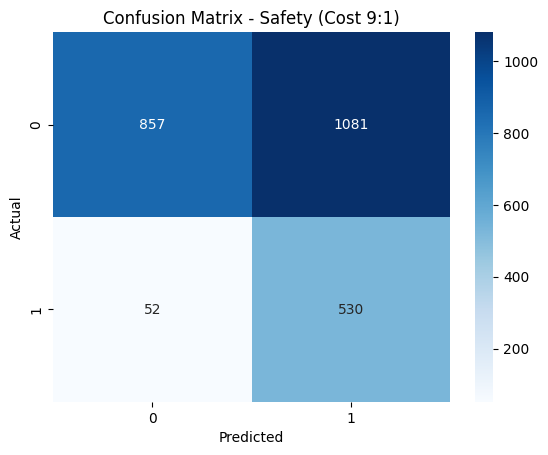

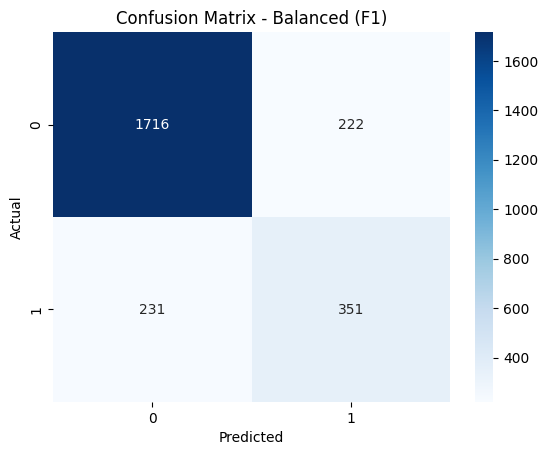

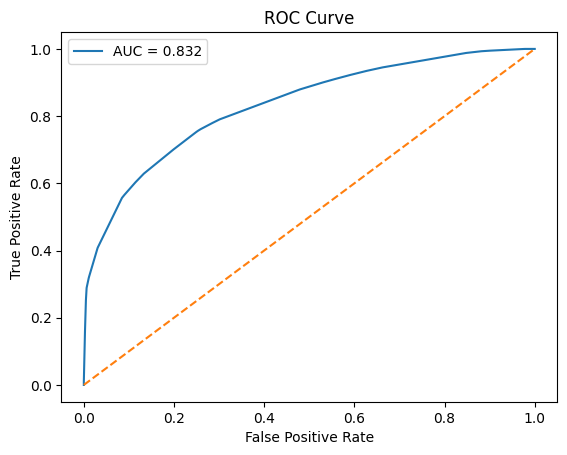

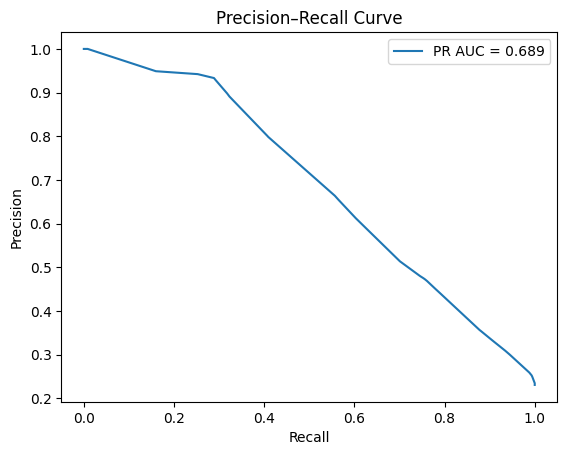

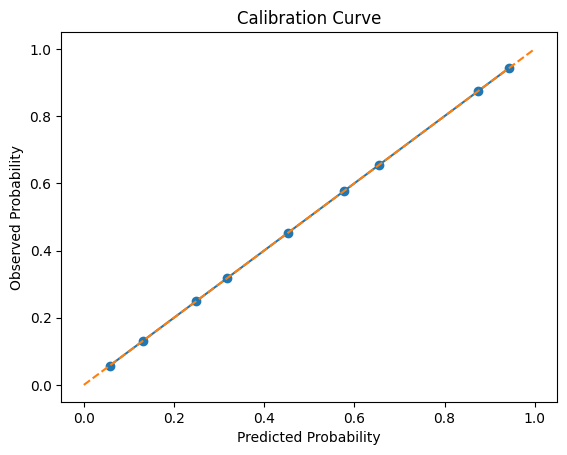

Raw Brier: 0.12117237032735696
Calibrated Brier: 0.11813901534883638


In [8]:
# Thresholds
# t_cost = 0.138687 this is for 5:1
t_cost = 0.099091
t_f1 = 0.297071

models = {
    "Safety (Cost 9:1)": t_cost,
    "Balanced (F1)": t_f1}

# CONFUSION MATRIX
def plot_cm(t, title):
    preds = (calibrated >= t).astype(int)
    cm = confusion_matrix(y, preds)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {title}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# ROC CURVE
def plot_roc():
    fpr, tpr, _ = roc_curve(y, calibrated)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

# PR CURVE
def plot_pr():
    precision, recall, _ = precision_recall_curve(y, calibrated)

    pr_auc = auc(recall, precision)

    plt.figure()
    plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision–Recall Curve")
    plt.legend()
    plt.show()

# CALIBRATION CURVE
def plot_calibration():
    prob_true, prob_pred = calibration_curve(y, calibrated, n_bins=10)

    plt.figure()
    plt.plot(prob_pred, prob_true, marker="o")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Observed Probability")
    plt.title("Calibration Curve")
    plt.show()

# Run the plots
for name, t in models.items():
    plot_cm(t, name)

plot_roc()
plot_pr()
plot_calibration()

print("Raw Brier:", brier_score_loss(y, meta_oof))
print("Calibrated Brier:", brier_score_loss(y, calibrated))

In [13]:
threshold = 0.099091

y_pred_cal = (calibrated >= threshold).astype(int)

print(f"Classification Report at Threshold = {threshold}\n")
print(classification_report(y, y_pred_cal))

print("Confusion Matrix:\n")
print(confusion_matrix(y, y_pred_cal))

print("Precision:", precision_score(y, y_pred_cal))
print("Recall:", recall_score(y, y_pred_cal))
print("F1 Score:", f1_score(y, y_pred_cal))
print("ROC AUC:", roc_auc_score(y, calibrated))

Classification Report at Threshold = 0.099091

              precision    recall  f1-score   support

           0       0.94      0.44      0.60      1938
           1       0.33      0.91      0.48       582

    accuracy                           0.55      2520
   macro avg       0.64      0.68      0.54      2520
weighted avg       0.80      0.55      0.57      2520

Confusion Matrix:

[[ 857 1081]
 [  52  530]]
Precision: 0.32898820608317814
Recall: 0.9106529209621993
F1 Score: 0.4833561331509348
ROC AUC: 0.8318079537837924


**Save variables for Streamlit dashboard**

In [16]:
import joblib

# Save variables for streamlit

# models
joblib.dump(rf_final, "rf.pkl")
joblib.dump(xgb_final, "xgb.pkl")
joblib.dump(cat_final, "cat.pkl")
joblib.dump(lr_final, "lr.pkl")
joblib.dump(meta_final, "meta.pkl")

# calibration
joblib.dump(iso, "calibrator.pkl")

# SHAP explainer
joblib.dump(explainer, "shap_explainer.pkl")

# features
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

# thresholds
joblib.dump(t_cost, "threshold_cost.pkl")
joblib.dump(t_f1, "threshold_f1.pkl")

['threshold_f1.pkl']